In [4]:
from google.colab import files

print("Lütfen bilgisayarınızdaki train.csv ve test.csv dosyalarını seçin:")
uploaded = files.upload()

# Dosyalar yüklendikten sonra normal okuma işlemine devam edebilirsin
import pandas as pd
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

Lütfen bilgisayarınızdaki train.csv ve test.csv dosyalarını seçin:


Saving test.csv to test.csv
Saving train.csv to train.csv


In [5]:
# Gerekli Kütüphaneler
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore') # Gereksiz kırmızı uyarıları gizler


train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("Train veri seti boyutu:", train.shape)
print("Test veri seti boyutu:", test.shape)

Train veri seti boyutu: (1460, 81)
Test veri seti boyutu: (1459, 80)


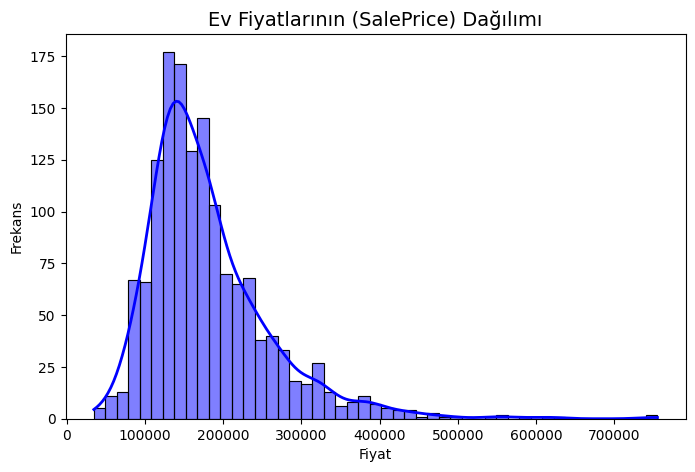

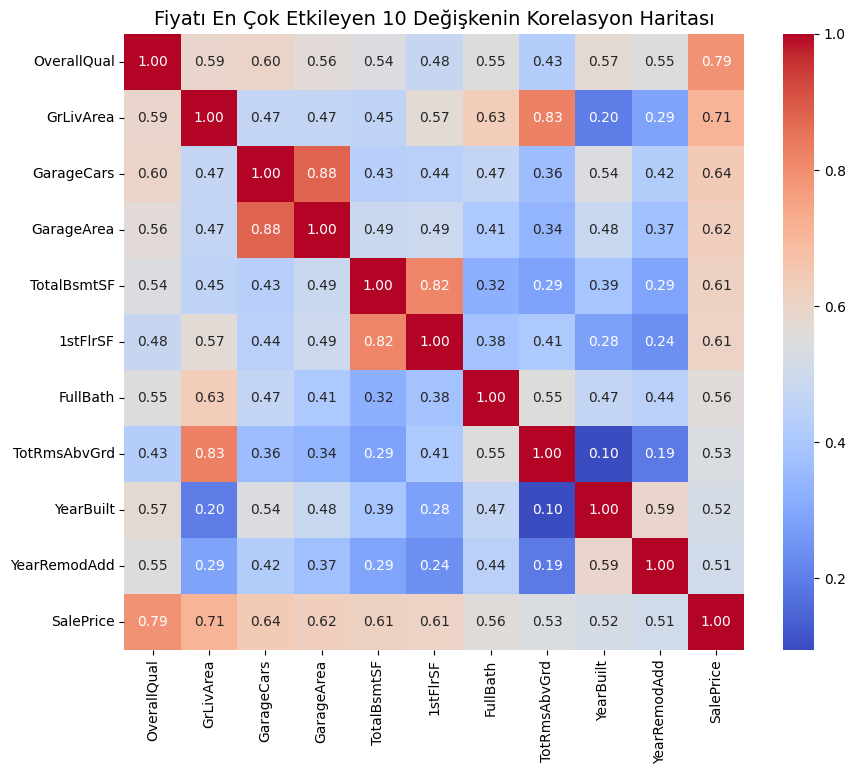

In [6]:
# 1. Hedef Değişkenin Dağılımı
plt.figure(figsize=(8, 5))
sns.histplot(train['SalePrice'], kde=True, color='blue', line_kws={'linewidth': 2})
plt.title("Ev Fiyatlarının (SalePrice) Dağılımı", fontsize=14)
plt.xlabel("Fiyat")
plt.ylabel("Frekans")
plt.show()

# 2. Korelasyon Haritası (Isı Haritası)
numeric_train = train.select_dtypes(include=[np.number])
correlation = numeric_train.corr()

# Fiyatı en çok etkileyen ilk 10 değişkeni bulalım
top_corr_features = correlation['SalePrice'].sort_values(ascending=False)[1:11].index

plt.figure(figsize=(10, 8))
# Bu değişkenlerin birbiriyle olan ilişkisinin ısı haritası
sns.heatmap(train[top_corr_features.to_list() + ['SalePrice']].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Fiyatı En Çok Etkileyen 10 Değişkenin Korelasyon Haritası", fontsize=14)
plt.show()

In [7]:
# Bağımlı (y) ve Bağımsız (X) değişkenleri ayır
y = train['SalePrice']
X = train.drop(['SalePrice', 'Id'], axis=1) # Id modeli yanıltır, çıkarıyorum
test_ids = test['Id']
test_X = test.drop(['Id'], axis=1)

# Sayısal ve Kategorik kolonları grupla
numeric_cols = X.select_dtypes(include=[np.number]).columns
categorical_cols = X.select_dtypes(exclude=[np.number]).columns

# Eksik Veri Doldurma (Imputation)
# Sayısalları medyan ile, kategorikleri "None" kelimesi ile dolduruyoruz
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())
test_X[numeric_cols] = test_X[numeric_cols].fillna(test_X[numeric_cols].median())

X[categorical_cols] = X[categorical_cols].fillna("None")
test_X[categorical_cols] = test_X[categorical_cols].fillna("None")

# One-Hot Encoding ve Hizalama
X = pd.get_dummies(X)
test_X = pd.get_dummies(test_X)

X, test_X = X.align(test_X, join='left', axis=1)
test_X = test_X.fillna(0) # Testte olmayan kolonlar için 0

print("Ön işleme tamamlandı. Model giriş boyutu:", X.shape)

Ön işleme tamamlandı. Model giriş boyutu: (1460, 303)


In [8]:
# Veriyi %80 Eğitim, %20 Doğrulama (Validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

#Model Karşılaştırılması
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, objective='reg:squarederror')
}


print("MODEL PERFORMANS KARŞILAŞTIRMASI")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)

    print(f"{name}:")
    print(f"  RMSE: {rmse:.2f} | MAE: {mae:.2f} | R^2 Skoru: {r2:.2f}\n")

MODEL PERFORMANS KARŞILAŞTIRMASI
Linear Regression:
  RMSE: 65386.51 | MAE: 21125.60 | R^2 Skoru: 0.44

Random Forest:
  RMSE: 29534.81 | MAE: 17776.59 | R^2 Skoru: 0.89

XGBoost:
  RMSE: 26063.43 | MAE: 16615.64 | R^2 Skoru: 0.91



GridSearchCV başlatılıyor...
En İyi Parametreler: {'max_depth': None, 'n_estimators': 100}


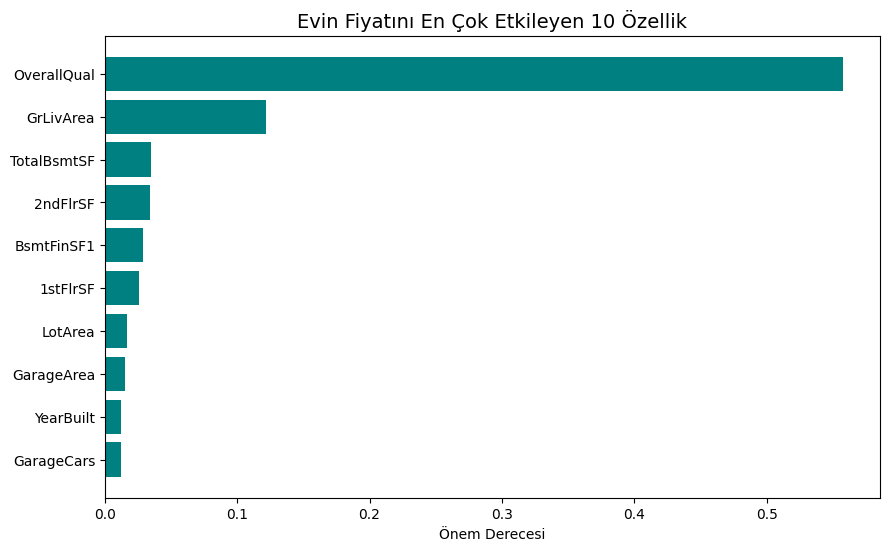

 Tahminler 'submission.csv' dosyasına başarıyla kaydedildi!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
print("GridSearchCV başlatılıyor...")

# Denenecek parametre kombinasyonları
param_grid = {
    'n_estimators': [100, 200], # Ağaç sayısı
    'max_depth': [10, 20, None] # Ağacın derinliği
}

# Modeli en iyi ayarları bulması için çapraz doğrulama ile çalıştırıyoruz
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"En İyi Parametreler: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

# Değişken Önem Derecesi (Feature Importance) Grafiği
importances = best_model.feature_importances_
indices = np.argsort(importances)[-10:] # En önemli 10 tanesini al

plt.figure(figsize=(10,6))
plt.title("Evin Fiyatını En Çok Etkileyen 10 Özellik", fontsize=14)
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Önem Derecesi')
plt.show()


# FİNAL TAHMİNİ VE KAGGLE İÇİN DOSYA OLUŞTURMA


# en iyi modelimizi bulduk göre,modeli son kez eğitiyoruz
best_model.fit(X, y)
final_test_preds = best_model.predict(test_X)

# Submission dosyasını oluştur
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': final_test_preds
})

submission.to_csv('submission.csv', index=False)
print(" Tahminler 'submission.csv' dosyasına başarıyla kaydedildi!")

# Dosyayı bilgisayara indir
from google.colab import files
files.download('submission.csv')